# Synthetic Ramesside Star Clocks

In [31]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os 
import pandas as pd
import matplotlib.pyplot as plt
import math

import star_chart_spherical_projection as scsp
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun, Angle, Longitude
from sunpy.coordinates import frames, sun

# I want get_sun to shut up so ignoring warnings:
import warnings
warnings.simplefilter('ignore', UserWarning)

In [107]:
def StarRiseSet(jd, starAlt, deg):
    # create return arrays
    star_rise = np.zeros(int(len(jd)/360), dtype=int)
    star_set = np.zeros(int(len(jd)/360), dtype=int)
    # loop through each day
    for i in range(360, len(jd) + 1, 360):
        # isolate data for one day
        dailyStarAlt = starAlt[i - 360 : i]
        # is the star visible at the beginning of the day
        starVis = dailyStarAlt[0] > deg
        # make array of booleans
        bool_arr = dailyStarAlt > deg   
        # find two indices of change
        ind1 = np.argwhere(bool_arr != starVis)[0][0]
        ind2 = np.argwhere(bool_arr[ind1:]== starVis)[0][0] + ind1
        # assign indices
        if starVis:
            star_set[int((i-360)/360)] = int(-360 + i  + ind1)
            star_rise[int((i-360)/360)] = int(-360 + i  + ind2)
        else:
            star_set[int((i-360)/360)] = int(-360 + i  + ind2)
            star_rise[int((i-360)/360)] = int(-360 + i  + ind1)
    return (star_rise, star_set)

def SunRiseSet(jd, SunAlt, deg):
    
    '''
    A function to create a list of indices where the Sun rises and sets in a given year. 
    This is useful for making sure we're tracking nightly, visible motion of the decans.
    NOTE: as written, this code assumes that data is collected every 4 minutes. 
    To change this, change number to number of collection intervals per day! (360 = 24 * 60/4)
    Inputs: 
        jd = Julian date
        SunAlt = the altitude of the Sun
    Outputs:
        sunriseset = indices of sunrize and sunset in the jd & date columns
    '''
    
    sunriseset = []
    for i in range(360, len(jd), 360):
        temp = []
        for j in range(i - 360, i):
            if SunAlt[j] <= deg + 0.4 and SunAlt[j] >= deg - 0.4:
                if len(temp) == 0: 
                    temp.append(j)
                elif temp[-1] != j - 1:
                    temp.append(j)
        sunriseset.append(temp)
    return sunriseset


def isStarVisible(sunSet, sunRise, starAlt):
    vis_arr = np.full(365, True)
    max_alt_arr = np.zeros(364)
    for i in range(0, 364):
        maxalt = max(starAlt[sunSet[i]:sunRise[i + 1]])
        max_alt_arr[i] = maxalt
        #print(maxalt)
        if maxalt < 0:
            vis_arr[i] = False
    return(max_alt_arr, vis_arr)

def MaxMinAltAz(jd, sunriseset, DecAz, DecAlt):
    
    '''
    A function to create lists of minimum and maximum azimuths and altitudes of the decan. 
    This is useful for making sure we're tracking nightly, visible motion of the decans.
    Inputs: 
        direct = string with the directory where the .txt file is located
        filename = string with name of file (name + month + year)
        jv = Julian date
        sunriseset = indices of sunrize and sunset in the jd & date columns
    Outputs:
        sunriseset = indices of sunrize and sunset in the jd & date columns
        days = list of indices when it's daylight 
        minaz, maxaz = minimum and maximum azimuths of the decan per night
        minalt, maxalt = minimum and maximum altitudes of the decan per night
        riseaz, setaz = azimuth of decan at rise & set
        risealt, setalt = altitude of decan at rise & set
    '''
    maxalt = []
    minalt = []
    maxaz = []
    minaz = []
    riseaz = []
    setaz = []
    risealt = []
    setalt = []
    days = []
    for i in range(0, int(len(jd)/360) - 1):
        sset = sunriseset[i][1]
        srise = sunriseset[i + 1][0]
        maxalt.append(max(DecAlt[sset:srise]))
        minalt.append(min(DecAlt[sset:srise]))
        maxaz.append(max(DecAz[sset:srise]))
        minaz.append(min(DecAz[sset:srise]))
        riseaz.append(DecAz[srise])
        setaz.append(DecAz[sset])
        risealt.append(DecAlt[srise])
        setalt.append(DecAlt[sset])
        days.append(DecAlt[srise:sset])
    return(days, minaz, maxaz, minalt, maxalt, riseaz, setaz, risealt, setalt)

## Re-do Plotting to Remind Myself How it Works

In [108]:
### Set the directory

starlist = ["Sirius", "Saiph", "Rigel", "Hamal", "Rasalhague", "Sheratan"]
starlist = ["Hamal", "Rasalhague", "Rigel", "Saiph", "Sheratan","Sirius"]

direct = os.getcwd() # current working directory
direct = direct + '/DecanLists' # directory where the .txt files go
filename = "/data1300BC.txt"

In [109]:
decanOutput = pd.read_csv(direct + filename, sep = "|")
# get header 
header = decanOutput.keys()
#
# get standard data
jd = decanOutput[header[0]].to_numpy()
hrd = decanOutput[header[1]]
sunAz = decanOutput[header[2]].to_numpy()
sunAlt = decanOutput[header[3]].to_numpy()
#
# get star data
num_decs = int( (len(header) - 4) / 2 ) # how many stars in list 
starsAz = np.zeros((num_decs, len(jd)))
starsAlt = np.zeros((num_decs, len(jd)))
for i in range(0, num_decs):
    starsAz[i, :] = decanOutput[header[4 + 2 * i]].to_numpy()
    starsAlt[i, :] = decanOutput[header[5 + 2 * i]].to_numpy()
   

In [110]:
# get sunrise and sunset times
(sunRise, sunSet) = StarRiseSet(jd, sunAlt, -12)
sunAzSet = sunAz[sunSet]

# get star rise and set times
starAzRiseList = np.zeros((num_decs, len(sunRise)))
starVisList = np.full((num_decs, len(sunRise)), True)
starMaxAltList = np.zeros((num_decs, len(sunRise)-1))

for i in range(0, num_decs):
    (starRise, starSet) = StarRiseSet(jd, starsAlt[i], 10)
    starAzRise = starsAz[i, starRise]
    starAzRiseList[i, :] = starAzRise
    (maxAlt, starVis) = isStarVisible(sunSet, sunRise, starsAlt[i])
    starVisList[i,:] = starVis
    starMaxAltList[i,:] = maxAlt


In [111]:
# if False in starVisList[i]:
#         np.where(starVisList[2] == False)

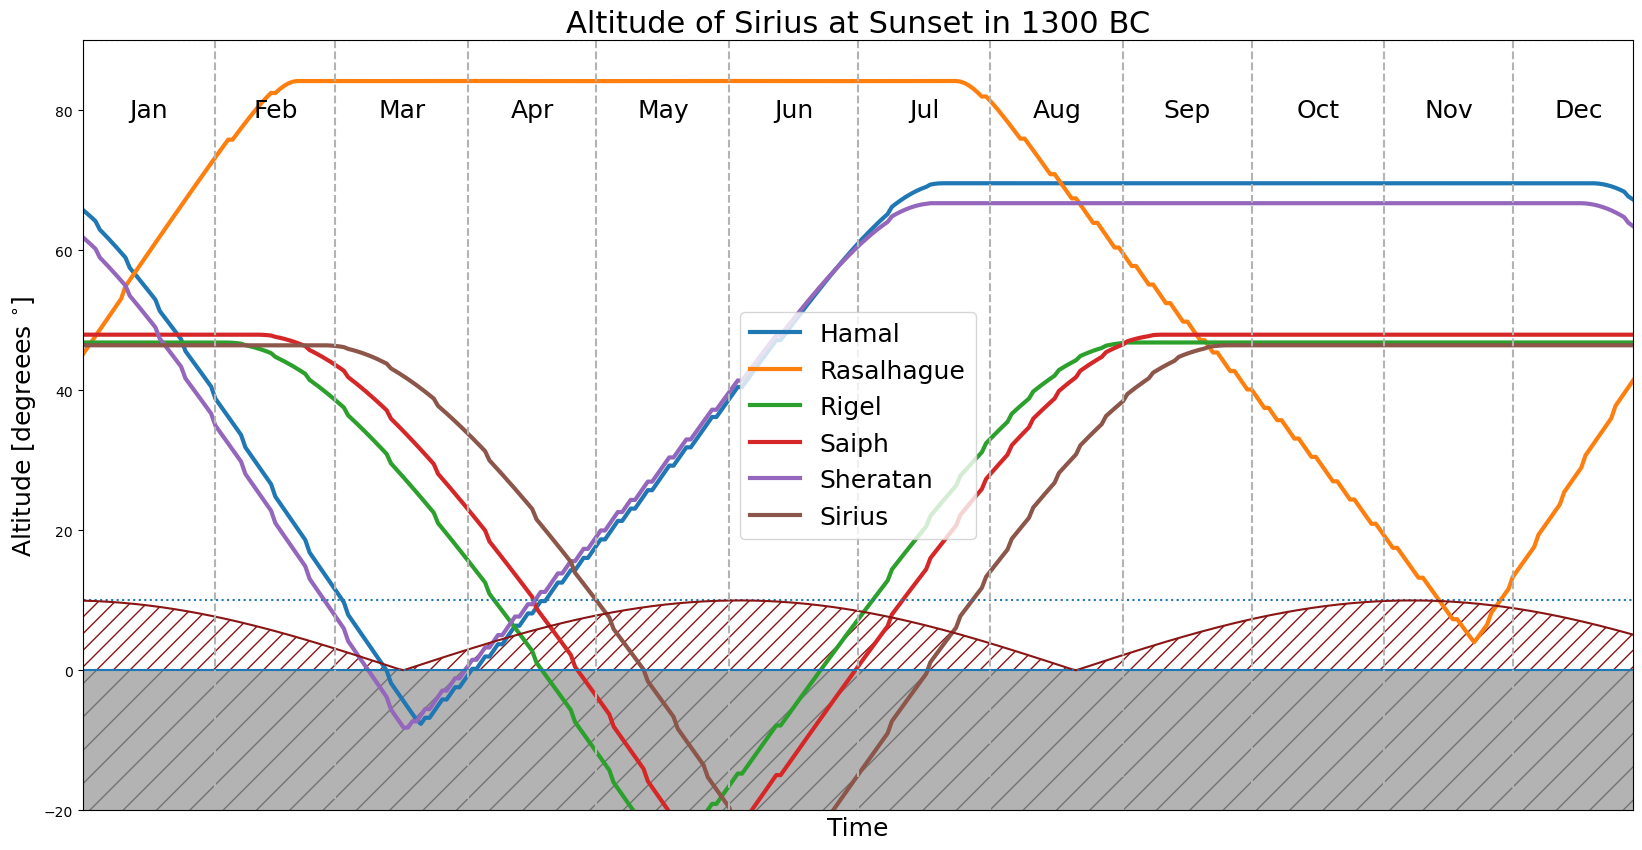

In [112]:
plt.figure(figsize=(20,10))

# plt.plot(xdays, SirSetAlt,  linewidth=3.0, label = 'Sunset')
# plt.plot(xdays, SirRiseAlt,  linewidth=3.0, label = 'Sunrise')
xdays = np.arange(1, len(starMaxAltList[0])+1)
y1 = np.abs(10 * np.sin(0.02 * xdays + 29.9))

for i in range(len(starlist)):
    plt.plot(xdays, starMaxAltList[i], linewidth=3.0, label = starlist[i])

# landscaping
plt.hlines(0, 0, 366)
plt.hlines(10, 0, 366, linestyle = ':')


# this makes the "mountain" effect
plt.plot(xdays, y1, color="#891515")
plt.fill_between(xdays, 0, y1,  facecolor="none", hatch="//", edgecolor="#891515", linewidth=0.0)
plt.fill_between(xdays, -30, 0, facecolor="0.7", hatch="/", edgecolor="0.45", linewidth=0.0)

# NESW LINES
ycoords = np.cumsum([-360, 90, 90, 90, 90, 90, 90, 90])
for yc in ycoords:
    plt.hlines(yc, 0, 366, linestyle = ':')

# month lines
mnth = [1, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
mnth_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
xcoords = np.cumsum(mnth) # vertical month lines
for xc in xcoords:
    plt.axvline(x=xc, linestyle = '--', color='0.7' )
    
# month labels

for i in range(0, 12):
    plt.text(xcoords[i + 1] - mnth[i+1]/2, 80, mnth_names[i], fontsize=18, horizontalalignment='center', verticalalignment='center')
    

#plt.fill_between(xdays[120 : 130 + 54 + 1], -360, 360,  facecolor="0.7", hatch="/", edgecolor="0.45", linewidth=0.0)    

 
# label shaded areas
#plt.text(153, 41, "Under the horizon", fontsize = '22',horizontalalignment='center', verticalalignment='center')    
 
    
# no x-label
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off

# niceties
plt.title('Altitude of Sirius at Sunset in 1300 BC', fontsize=22)    
plt.ylabel(r'Altitude [degreees $^{\circ}$]', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.xlim(1, 363)
plt.ylim(-20, 90)
plt.legend(fontsize = 18)
plt.show()

## Create Synthetic RSC function

In [113]:
def horizonBins(horizon, bsize, gsize):
    # if gap size is zero, return as usual
    if gsize == 0:
        return((np.linspace(horizon[0], horizon[1], 8), 1))
    # otherwise, divide into smallest common denominator
    num = 7 * bsize + 7 * gsize
    horizon_bins = np.linspace(horizon[0], horizon[1], num)
    # select indices to merge by bin/gap size
    ## first gaps
    ind_gap = np.zeros(14)
    ind_gap[1::2] = np.arange(0,7)
    ind_gap[::2] = np.arange(0,7)
    ## then bins
    ind_bin = np.zeros(14)
    ind_bin[0:13] = ind_gap[1:]
    ind_bin[-1] = 7
    # add together with bin/gap sizes
    inds = ind_bin * bsize + ind_gap * gsize
    inds = inds.astype(int)
    # return only those bin and gap indices
    return((horizon_bins[inds], 2))

def synRSC(date_ind, horizon, bsize, gsize, sunSet, sunRise, starAz, starVis):
    '''Function which, when given a date, size of horizon, and star data*, 
    makes a synthetic Ramesside Star Clock.'''
    # define horizon bin limits (assuming equal binsize)
    (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
    # define time bin limits (assuming equal binsize)
    sset = sunSet[date_ind]
    sris = sunRise[date_ind + 1]
    #time_bins = np.linspace(jd[sset], jd[srise], 14)
    time_ind_bins = np.round(np.linspace(sset, sris, 13))
    # bin star as appropriate 
    rsc_table = []
    for i in range(0, 13):
        ind = int(time_ind_bins[i])
        if starVis[date_ind]:
            az_list = starAz[ind]
            row = np.histogram(az_list, horizon_bins)[0][0:-1:skip]
            print("hour " + "{:02d}".format(i), row)
        else:
            row = np.zeros(7)       
        rsc_table.append(row)
    return(np.array(rsc_table))

In [117]:
horizon = (170, 190)
star_ind = -1
bsize = 1
gsize = 0

print("Data for {0}".format(starlist[star_ind]))
print("Horizon definition: " + str(horizon))
for i in range(0, 24):
    print("Table No.%2d"%(i + 1))
    rsc_table = synRSC(i * 15, horizon, bsize, gsize, sunSet, sunRise, starsAz[star_ind], starVisList[star_ind])

Data for Sirius
Horizon definition: (170, 190)
Table No. 1
hour 00 [0 0 0 0 0 0]
hour 01 [0 0 0 0 0 0]
hour 02 [0 0 0 0 0 0]
hour 03 [0 0 0 0 0 0]
hour 04 [0 1 0 0 0 0]
hour 05 [0 0 0 0 0 0]
hour 06 [0 0 0 0 0 0]
hour 07 [0 0 0 0 0 0]
hour 08 [0 0 0 0 0 0]
hour 09 [0 0 0 0 0 0]
hour 10 [0 0 0 0 0 0]
hour 11 [0 0 0 0 0 0]
hour 12 [0 0 0 0 0 0]
Table No. 2
hour 00 [0 0 0 0 0 0]
hour 01 [0 0 0 0 0 0]
hour 02 [0 0 0 0 0 0]
hour 03 [0 0 1 0 0 0]
hour 04 [0 0 0 0 0 0]
hour 05 [0 0 0 0 0 0]
hour 06 [0 0 0 0 0 0]
hour 07 [0 0 0 0 0 0]
hour 08 [0 0 0 0 0 0]
hour 09 [0 0 0 0 0 0]
hour 10 [0 0 0 0 0 0]
hour 11 [0 0 0 0 0 0]
hour 12 [0 0 0 0 0 0]
Table No. 3
hour 00 [0 0 0 0 0 0]
hour 01 [0 0 0 0 0 0]
hour 02 [0 0 0 1 0 0]
hour 03 [0 0 0 0 0 0]
hour 04 [0 0 0 0 0 0]
hour 05 [0 0 0 0 0 0]
hour 06 [0 0 0 0 0 0]
hour 07 [0 0 0 0 0 0]
hour 08 [0 0 0 0 0 0]
hour 09 [0 0 0 0 0 0]
hour 10 [0 0 0 0 0 0]
hour 11 [0 0 0 0 0 0]
hour 12 [0 0 0 0 0 0]
Table No. 4
hour 00 [0 0 0 0 0 0]
hour 01 [0 0 0 0 1 0]
hou

Code tweaks:

- ~~label the rows~~

- ~~implement nautical twilight~~ 

- ~~how about bins not being continuous? add "inbetween bins" that get thrown out before printing~~

- make a dictionary of stars I'm using and their abbreviations as I add more stars 

- make fake stars with fixed dec and magnitude spaced 1 hour around and see what they do (SH1 - SH24)?

- ~~parametrize such that bins are equal but not necessarily the same width as the inbetween throwaway bins.~~

- do 24-star structures (might want several bands of these eventually)

- start with Sirius + [1,23] * 1 RA HA

- what happens when two stars fall in the same bin at the same time? Raise exception? Or make them print side-by-side? Somehow mark it 

- mark them S00, S01, S02.... (will make it easier later)

- organize output in some way of like a CSV (with all input parameters marked) so it could reasobaly be imported into excel or something. 

In [29]:
#horizon = (170, 190)
star_ind = -1

print("Data for {0}".format(starlist[star_ind]))
print("Horizon definition: sunset")
for i in range(0, 24):
    print("Table No.%2d"%(i + 1))
    horizon = (sunAzSet[i] - 10, sunAzSet[i] + 10)
    rsc_table = synRSC(i * 15, horizon, sunSet, sunRise, starsAz[star_ind], starVisList[star_ind])

NameError: name 'starlist' is not defined

In [207]:
#horizon = (170, 190)
star_ind = -1

print("Data for {0}".format(starlist[star_ind]))
print("Horizon definition: anti-sunset")
for i in range(0, 24):
    print("Table No.%2d"%(i + 1))
    horizon = (360 - 1 * sunAzSet[i] - 10, 360 - 1 * sunAzSet[i] + 10)
    rsc_table = synRSC(i * 15, horizon, sunSet, sunRise, starsAz[star_ind], starVisList[star_ind])

Data for Sirius
Horizon definition: anti-sunset
Table No. 1
[0 1 0 0 0 0 0]
[0 0 0 0 1 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
Table No. 2
[0 0 0 0 1 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
Table No. 3
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
Table No. 4
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
Table No. 5
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0